<a href="https://colab.research.google.com/github/LetheeshBalaji/24ADI003-24BAD063/blob/main/Exp_3_scenario_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "StudentsPerformance.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "spscientist/students-performance-in-exams",
    file_path
)


print(df.head())
print("Letheesh Balaji")
print("24BAD063")


Using Colab cache for faster access to the 'students-performance-in-exams' dataset.
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
Letheesh Balaji
24BAD063


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import mean_squared_error, r2_score

In [ ]:

import pandas as pd
df_encoded = pd.get_dummies(df, columns=['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course'], drop_first=True)

X = df_encoded.drop(columns=['math score'])
y = df_encoded['math score']

In [ ]:


imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [ ]:


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = lr_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

MSE: 29.10
RMSE: 5.39
R² Score: 0.88


In [ ]:
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
print(coefficients.sort_values(by='Coefficient', ascending=False))

                                          Feature  Coefficient
1                                   writing score    10.998400
2                                     gender_male     6.528208
0                                   reading score     3.444251
6                          race/ethnicity_group E     1.697686
12                                 lunch_standard     1.679618
13                   test preparation course_none     1.577094
10       parental level of education_some college     0.417761
8         parental level of education_high school     0.368908
11   parental level of education_some high school     0.289995
3                          race/ethnicity_group B     0.140963
7   parental level of education_bachelor's degree    -0.231278
5                          race/ethnicity_group D    -0.269654
4                          race/ethnicity_group C    -0.291593
9     parental level of education_master's degree    -0.329990


In [ ]:
from sklearn.linear_model import Ridge, Lasso

# Ridge Optimization
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Lasso Optimization (Feature Elimination)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

print(f"Ridge R²: {ridge.score(X_test, y_test):.2f}")
print(f"Lasso R²: {lasso.score(X_test, y_test):.2f}")

Ridge R²: 0.88
Lasso R²: 0.88


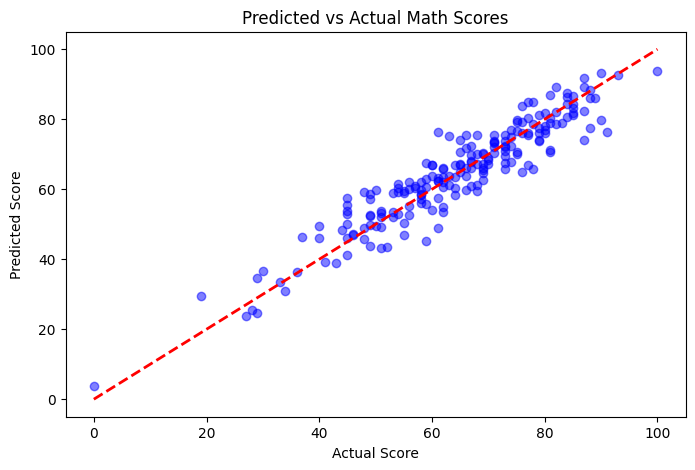

/tmp/ipython-input-641474136.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coefficients, palette='viridis')


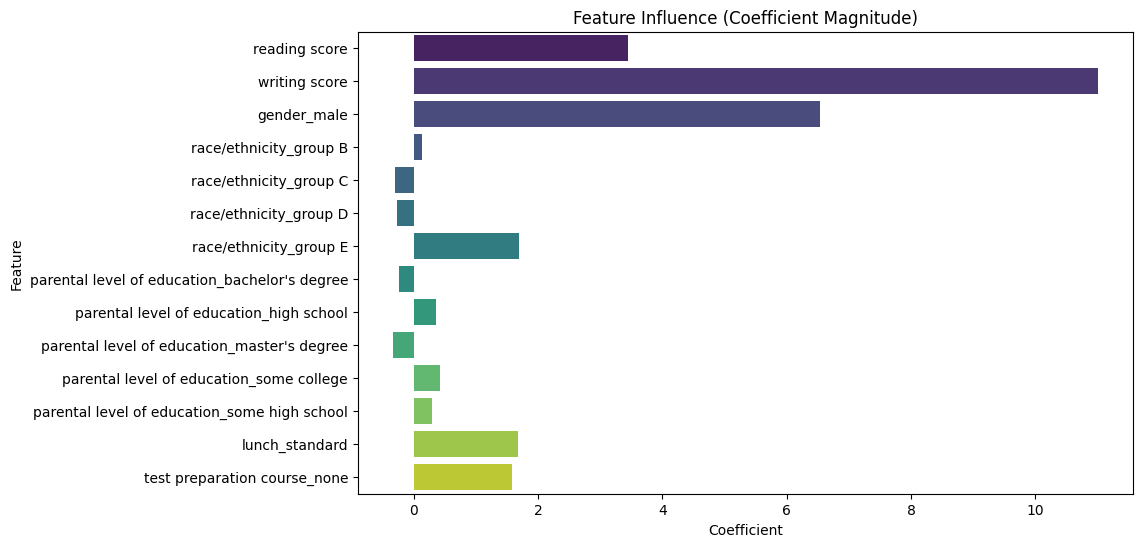

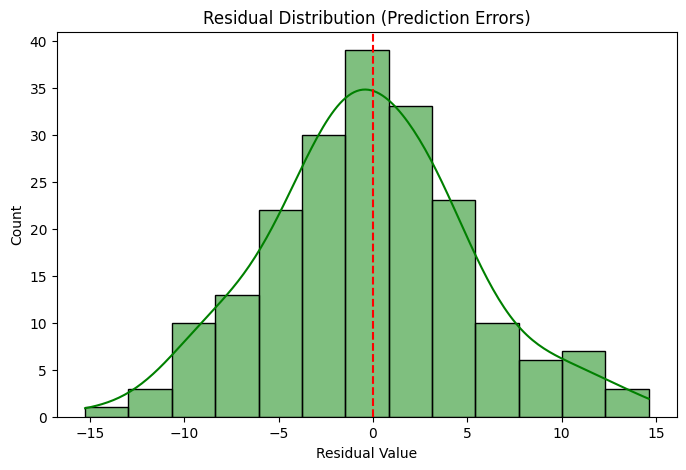

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title('Predicted vs Actual Math Scores')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.show()

# 2. Coefficient Magnitude Graph
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients, palette='viridis')
plt.title('Feature Influence (Coefficient Magnitude)')
plt.show()

# 3. Residual Distribution Graph
plt.figure(figsize=(8, 5))
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='green')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Residual Distribution (Prediction Errors)')
plt.xlabel('Residual Value')
plt.show()